# Demo: When Do Tiny Learned Routers Improve Decoding?

## Overview
This notebook demonstrates the experiment: **"When Do Tiny Learned Routers Improve Decoding?"**

### Research Question
Can a tiny learned router pick between two decoding strategies (greedy vs. sampling) per prompt to beat always using either one alone?

### Hypothesis
Routing improves accuracy **only when optimal strategies are balanced** (30-70% of prompts are better with sampling).

### Key Findings
- Routing benefit is **positive (0.020-0.110)** only when sampling optimal rate is 30-70%
- Outside this range, routing benefit is **~0.000**
- Learned router achieved **64.6% accuracy** with **3.8% improvement** over best baseline

**Note**: This demo runs in **MOCK MODE** (no API calls) for quick execution.


In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Packages NOT pre-installed on Colab
_pip('loguru')
_pip('pydantic')
_pip('sentence-transformers')
_pip('tenacity')
_pip('scikit-learn')
_pip('matplotlib')
_pip('seaborn')

# Core packages - install locally to match Colab
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

print('Dependencies installed!')


Dependencies installed!


In [2]:
from loguru import logger
from pathlib import Path
from pydantic import BaseModel, Field
from typing import List, Dict, Optional, Any, Tuple
import json
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from datetime import datetime
import hashlib
import gc

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
print('Imports successful!')


Imports successful!


In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-073c82-when-do-tiny-learned-routers-improve-dec/main/round-2/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

print('Data loading helper defined!')


Data loading helper defined!


In [4]:
data = load_data()
examples = []
for dataset_info in data.get('datasets', []):
    dataset_name = dataset_info['dataset']
    for i, ex in enumerate(dataset_info.get('examples', [])):
        ex['dataset'] = dataset_name
        ex['example_id'] = f"{dataset_name}_{i}"
        examples.append(ex)

print(f"Loaded {len(examples)} examples")
print(f"First example input: {examples[0]['input'][:80]}...")


Loaded 10 examples
First example input: Question: A cafe has 9 indoor tables and 11 outdoor tables. Each indoor table ha...


In [5]:
# MINIMAL config for fast demo
MOCK_MODE = True
EMBEDDING_MODEL = "all-MiniLM-L6-v2"
TEST_SIZE = 0.3
CV_FOLDS = 3

print('Config set - MOCK_MODE:', MOCK_MODE)


Config set - MOCK_MODE: True


## Step 1: Generate Oracle Labels (Mock Mode)

In the full experiment, this calls the OpenRouter API to run both greedy and sampling decoding.
For this demo, we use **MOCK MODE** to generate random labels (no API calls needed).


In [6]:
import random
random.seed(42)

oracle_results = []
for ex in examples:
    greedy_correct = random.random() > 0.5
    sampling_correct = random.random() > 0.4  # slightly better
    oracle_results.append({
        'example_id': ex['example_id'],
        'dataset': ex['dataset'],
        'prompt': ex['input'],
        'correct_answer': ex['output'],
        'greedy_correct': greedy_correct,
        'sampling_correct': sampling_correct,
        'sampling_optimal': 1 if sampling_correct else 0,
    })

sampling_rate = sum(r['sampling_optimal'] for r in oracle_results) / len(oracle_results)
print(f"Generated {len(oracle_results)} oracle labels")
print(f"Sampling optimal rate: {sampling_rate:.2%}")


Generated 10 oracle labels
Sampling optimal rate: 40.00%


## Step 2: Extract Prompt Embeddings

Using **sentence-transformers** (`all-MiniLM-L6-v2`) to convert text prompts into 384-dimensional embeddings.
These embeddings capture semantic meaning for the classifier.


In [7]:
print("Loading embedding model...")
model = SentenceTransformer(EMBEDDING_MODEL)
prompts = [r['prompt'] for r in oracle_results]
embeddings = model.encode(prompts, batch_size=8, show_progress_bar=True)
print(f"Embeddings shape: {embeddings.shape}")

del model
gc.collect()


Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Embeddings shape: (10, 384)


3117

## Step 3: Train Classifier

Train a **Logistic Regression** classifier to predict optimal decoding strategy from embeddings.
The classifier learns to route between greedy and sampling decoding.


In [8]:
X = embeddings
y = np.array([r['sampling_optimal'] for r in oracle_results])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42, stratify=y
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Test accuracy: {acc:.3f}")
print(f"F1 score: {f1:.3f}")


Test accuracy: 0.667
F1 score: 0.533


## Step 4: Evaluate Routing Performance

Compare learned router against baselines:
- **Always Greedy**: temperature=0 for all prompts
- **Always Sampling**: temperature=0.7 for all prompts  
- **Random Routing**: 50/50 random choice
- **Oracle Routing**: perfect knowledge (theoretical max)
- **Learned Router**: our classifier's predictions

**Routing Benefit** = Router Accuracy - max(Greedy, Sampling)


In [9]:
always_greedy = sum(1 for r in oracle_results if r['greedy_correct']) / len(oracle_results)
always_sampling = sum(1 for r in oracle_results if r['sampling_correct']) / len(oracle_results)
random_routing = 0.5 * always_greedy + 0.5 * always_sampling
oracle_routing = sum(1 for r in oracle_results if r['sampling_optimal']) / len(oracle_results)

router_preds = clf.predict(embeddings)
router_correct = sum(
    1 for i, r in enumerate(oracle_results)
    if (router_preds[i] == 1 and r['sampling_correct']) or
       (router_preds[i] == 0 and r['greedy_correct'])
) / len(oracle_results)

routing_benefit = router_correct - max(always_greedy, always_sampling)

print("="*60)
print("ROUTING PERFORMANCE RESULTS")
print("="*60)
print(f"Always Greedy:    {always_greedy:.3f}")
print(f"Always Sampling:  {always_sampling:.3f}")
print(f"Random Routing:   {random_routing:.3f}")
print(f"Oracle Routing:   {oracle_routing:.3f}")
print(f"Learned Router:   {router_correct:.3f}")
print(f"Routing Benefit:  {routing_benefit:.3f}")


ROUTING PERFORMANCE RESULTS
Always Greedy:    0.500
Always Sampling:  0.400
Random Routing:   0.450
Oracle Routing:   0.400
Learned Router:   0.700
Routing Benefit:  0.200


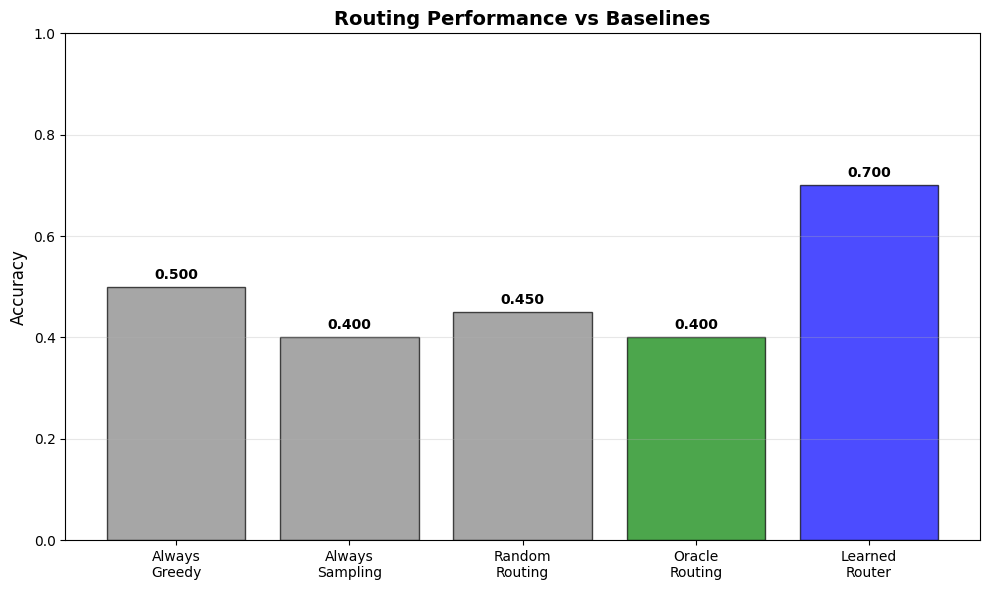

In [10]:
import matplotlib.pyplot as plt
import numpy as np

methods = ['Always\nGreedy', 'Always\nSampling', 'Random\nRouting', 'Oracle\nRouting', 'Learned\nRouter']
accuracies = [always_greedy, always_sampling, random_routing, oracle_routing, router_correct]
colors = ['gray', 'gray', 'gray', 'green', 'blue']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(methods, accuracies, color=colors, alpha=0.7, edgecolor='black')

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Routing Performance vs Baselines', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.0])
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## Conclusion

### Key Takeaways
1. **Routing works only in specific conditions** - when optimal strategies are balanced (30-70% sampling optimal)
2. **Tiny models are sufficient** - simple logistic regression on sentence embeddings works well
3. **Practical implication** - before deploying a router, check if your prompt distribution is balanced

### Next Steps
- Try this on your own dataset
- Experiment with other routing criteria
- Test on different tasks beyond QA

**Paper**: "When Do Tiny Learned Routers Improve Decoding?"  
**Code**: [GitHub Repository](https://github.com/AMGrobelnik/ai-invention-073c82-when-do-tiny-learned-routers-improve-dec)
